In [26]:
import numpy as np
from collections import defaultdict
import glob
import json
import pandas as pd
from scipy.integrate import quad, dblquad
import matplotlib.pyplot as plt
import re

class Position2:
  def __init__(self, x=0.0, y=0.0):
    self.x = x
    self.y = y

# Experiment Setup

In [27]:
START_POS = Position2(x=450.0, y=300.0)

OBJECTS_GROUND_TRUTH = {
  "ball": Position2(x=550.0, y=350.0),
  "robot": Position2(x=650.0, y=200.0),
  "X-Intersection": Position2(x=750.0, y=300.0),
  "L-Intersection": Position2(x=800.0, y=450.0),
  "T-Intersection": Position2(x=900.0, y=450.0),
  "goalpost": Position2(x=900.0, y=170.0), # Left goalpost
}

# Load Data

In [28]:
def load_ipm_estimations(path, labels=None):
  if labels is None:
    labels = OBJECTS_GROUND_TRUTH.keys()   
  estimated = {label: [] for label in labels}
  with open(path, "r") as f:
    data = json.load(f)
    for frame in data:
      for obj in frame:
        label = obj["label"]
        if label in estimated:
          pos = Position2(x=obj["field_x"], y=obj["field_y"])
          robot = Position2(obj["robot_x"], obj["robot_y"])
          estimated[label].append((pos, robot))
  
  return estimated


dynamic_ipm = []
files = sorted(
    glob.glob("../data/dynamic_ipm_logs_*.json"),
    key=lambda x: int(re.search(r'_(\d+)\.json', x).group(1))
)

for filename in files:
    data = load_ipm_estimations(filename, ["ball", "robot", "X-Intersection", "goalpost"])
    dynamic_ipm.append(data)

# IPM Evaluation

### Error Metrices

In [29]:
def estimated_position_errors(estimated: Position2, actual: Position2, robot: Position2):
  dx = estimated.x - actual.x
  dy = estimated.y - actual.y
  err = np.hypot(dx, dy)

  rel_dx = actual.x - robot.x
  rel_dy = actual.y - robot.y
  dist = np.hypot(rel_dx, rel_dy)

  err_pct = (err / dist) * 100 if dist != 0 else 0.0

  x_pct = (abs(dx) / abs(rel_dx)) * 100 if rel_dx != 0 else 0.0
  y_pct = (abs(dy) / abs(rel_dy)) * 100 if rel_dy != 0 else 0.0

  return dx, dy, err, x_pct, y_pct, err_pct

### Static Evaluation

In [30]:
static_ipm = load_ipm_estimations("../data/static_ipm_logs.json")

def print_summary_static(title, data, results):
  errors, x_errors, y_errors, x_pct, y_pct, err_pct = results

  print(f"=== {title} ===")

  for label, entries in data.items():
    if len(entries) == 0:
      continue

    xs = [est.x for est, _ in entries]
    ys = [est.y for est, _ in entries]

    avg_x = np.mean(xs)
    avg_y = np.mean(ys)

    mean_err = np.mean(errors[label])
    mean_err_pct = np.mean(err_pct[label])

    mean_dx = np.mean(x_errors[label])
    mean_dy = np.mean(y_errors[label])

    mean_x_pct = np.mean(x_pct[label])
    mean_y_pct = np.mean(y_pct[label])

    print(f"{label}:")
    print(f"  Avg Position : ({avg_x:.1f}, {avg_y:.1f})")
    print(f"  Mean Error   : {mean_err:.1f} ({mean_err_pct:.1f}%)")
    print(f"  Mean X Error : {mean_dx:.1f} ({mean_x_pct:.1f}%)")
    print(f"  Mean Y Error : {mean_dy:.1f} ({mean_y_pct:.1f}%)")
    print()

def evaluate_static(data):
  errors = defaultdict(list)
  x_errors = defaultdict(list)
  y_errors = defaultdict(list)
  x_pct_errors = defaultdict(list)
  y_pct_errors = defaultdict(list)
  err_pct_errors = defaultdict(list)

  for label, entries in data.items():
    actual = OBJECTS_GROUND_TRUTH[label]

    for est, robot in entries:
      dx, dy, err, x_pct, y_pct, err_pct = estimated_position_errors(est, actual, robot)

      x_errors[label].append(dx)
      y_errors[label].append(dy)
      errors[label].append(err)
      x_pct_errors[label].append(x_pct)
      y_pct_errors[label].append(y_pct)
      err_pct_errors[label].append(err_pct)

  return errors, x_errors, y_errors, x_pct_errors, y_pct_errors, err_pct_errors

static_results = evaluate_static(static_ipm)
print_summary_static("STATIC IPM", static_ipm, static_results)

=== STATIC IPM ===
ball:
  Avg Position : (548.1, 351.5)
  Mean Error   : 2.5 (2.2%)
  Mean X Error : -1.9 (1.9%)
  Mean Y Error : 1.5 (3.1%)

robot:
  Avg Position : (642.5, 200.5)
  Mean Error   : 7.5 (3.4%)
  Mean X Error : -7.5 (3.8%)
  Mean Y Error : 0.5 (0.5%)

X-Intersection:
  Avg Position : (752.3, 300.6)
  Mean Error   : 2.4 (0.8%)
  Mean X Error : 2.3 (0.8%)
  Mean Y Error : 0.6 (0.0%)

L-Intersection:
  Avg Position : (804.2, 443.6)
  Mean Error   : 7.7 (2.0%)
  Mean X Error : 4.2 (1.2%)
  Mean Y Error : -6.4 (4.3%)

T-Intersection:
  Avg Position : (930.1, 460.4)
  Mean Error   : 31.8 (6.7%)
  Mean X Error : 30.1 (6.7%)
  Mean Y Error : 10.4 (6.9%)

goalpost:
  Avg Position : (967.4, 168.7)
  Mean Error   : 67.4 (14.4%)
  Mean X Error : 67.4 (15.0%)
  Mean Y Error : -1.3 (1.0%)



### Dynamic Evaluation

#### Detecting outliers
Outlier exist because of false object detection

In [31]:
def detect_outliers_iqr(values):
  q1 = np.percentile(values, 25)
  q3 = np.percentile(values, 75)
  iqr = q3 - q1

  lower = max(0.0, q1 - 1.5 * iqr)
  upper = q3 + 1.5 * iqr

  mask = [(v < lower) or (v > upper) for v in values]
  return mask, lower, upper

def find_outliers_per_object(runs):
  outliers = {}

  for label in OBJECTS_GROUND_TRUTH.keys():
    all_errors = []
    all_entries = []

    for run in runs:
      if label not in run:
        continue

      actual = OBJECTS_GROUND_TRUTH[label]

      for est, robot in run[label]:
        dx = est.x - actual.x
        dy = est.y - actual.y
        err = np.hypot(dx, dy)

        all_errors.append(err)
        all_entries.append((est, robot, err))

    if len(all_errors) == 0:
      continue

    mask, lower, upper = detect_outliers_iqr(all_errors)

    outliers[label] = []
    for i, is_outlier in enumerate(mask):
      if is_outlier:
        est, robot, err = all_entries[i]
        outliers[label].append((est.x, est.y, err))

    print(f"{label}:")
    print(f"  Bounds: [{lower:.2f}, {upper:.2f}]")
    print(f"  Outliers: {len(outliers[label])}/{len(all_errors)}")

    for o in outliers[label][:5]:
      print(f"    ({o[0]:.2f}, {o[1]:.2f}) -> Error {o[2]:.2f}")

    print()

  return outliers

outliers = find_outliers_per_object(dynamic_ipm)

ball:
  Bounds: [0.00, 25.46]
  Outliers: 6/364
    (577.04, 353.81) -> Error 27.30
    (544.42, 311.12) -> Error 39.27
    (545.65, 314.78) -> Error 35.48
    (538.51, 309.73) -> Error 41.88
    (538.65, 314.72) -> Error 37.06

robot:
  Bounds: [0.00, 55.68]
  Outliers: 1/411
    (-784.39, 3779.38) -> Error 3856.09

X-Intersection:
  Bounds: [0.00, 56.97]
  Outliers: 8/214
    (548.32, 185.19) -> Error 232.07
    (546.05, 197.37) -> Error 228.32
    (573.80, 201.88) -> Error 201.68
    (744.83, 492.13) -> Error 192.20
    (751.30, 486.40) -> Error 186.41

goalpost:
  Bounds: [24.67, 117.14]
  Outliers: 22/205
    (891.61, 186.92) -> Error 18.89
    (800.37, 262.56) -> Error 135.99
    (770.71, 269.37) -> Error 163.06
    (810.74, 259.55) -> Error 126.44
    (818.61, 403.08) -> Error 246.88



#### Removing outliers

In [32]:
def filter_outliers_per_object(runs, exclude_labels=None):
  if exclude_labels is None:
    exclude_labels = []

  filtered_runs = []

  for run in runs:
    new_run = {}

    for label, entries in run.items():
      if label not in OBJECTS_GROUND_TRUTH:
        continue

      if label in exclude_labels:
        new_run[label] = entries
        continue

      actual = OBJECTS_GROUND_TRUTH[label]

      errors = []
      for est, robot in entries:
        dx = est.x - actual.x
        dy = est.y - actual.y
        err = np.hypot(dx, dy)
        errors.append(err)

      if len(errors) == 0:
        new_run[label] = entries
        continue

      q1 = np.percentile(errors, 25)
      q3 = np.percentile(errors, 75)
      iqr = q3 - q1

      lower = max(0.0, q1 - 1.5 * iqr)
      upper = q3 + 1.5 * iqr

      filtered_entries = []
      for (est, robot), err in zip(entries, errors):
        if lower <= err <= upper:
          filtered_entries.append((est, robot))

      new_run[label] = filtered_entries

    filtered_runs.append(new_run)

  return filtered_runs

filtered_dynamic_ipm = filter_outliers_per_object(
  dynamic_ipm,
  exclude_labels=["ball"]
)

#### Evaluation

In [33]:
def print_summary_dynamic(title, runs, results):
  errors, x_errors, y_errors, x_pct, y_pct, err_pct = results

  all_labels = set()
  for run in runs:
    all_labels.update(run.keys())

  print(f"=== {title} ===")

  for label in all_labels:
    xs, ys = [], []

    for run in runs:
      if label in run:
        xs.extend([est.x for est, _ in run[label]])
        ys.extend([est.y for est, _ in run[label]])

    if len(xs) == 0:
      continue

    avg_x = np.mean(xs)
    avg_y = np.mean(ys)

    mean_err = np.mean(errors[label])
    mean_err_pct = np.mean(err_pct[label])

    mean_dx = np.mean(x_errors[label])
    mean_dy = np.mean(y_errors[label])

    mean_x_pct = np.mean(x_pct[label])
    mean_y_pct = np.mean(y_pct[label])

    print(f"{label}:")
    print(f"  Avg Position : ({avg_x:.1f}, {avg_y:.1f})")
    print(f"  Mean Error   : {mean_err:.1f} ({mean_err_pct:.1f}%)")
    print(f"  Mean X Error : {mean_dx:.1f} ({mean_x_pct:.1f}%)")
    print(f"  Mean Y Error : {mean_dy:.1f} ({mean_y_pct:.1f}%)")
    print()

def evaluate_dynamic(runs):
  errors = defaultdict(list)
  x_errors = defaultdict(list)
  y_errors = defaultdict(list)
  x_pct_errors = defaultdict(list)
  y_pct_errors = defaultdict(list)
  err_pct_errors = defaultdict(list)

  for run in runs:
    for label, entries in run.items():
      if label not in OBJECTS_GROUND_TRUTH:
        continue

      actual = OBJECTS_GROUND_TRUTH[label]

      for est, robot in entries:
        dx, dy, err, x_pct, y_pct, err_pct = estimated_position_errors(est, actual, robot)

        x_errors[label].append(dx)
        y_errors[label].append(dy)
        errors[label].append(err)
        x_pct_errors[label].append(x_pct)
        y_pct_errors[label].append(y_pct)
        err_pct_errors[label].append(err_pct)

  return errors, x_errors, y_errors, x_pct_errors, y_pct_errors, err_pct_errors

dynamic_results = evaluate_dynamic(filtered_dynamic_ipm)
print_summary_dynamic("DYNAMIC IPM", filtered_dynamic_ipm, dynamic_results)

=== DYNAMIC IPM ===
goalpost:
  Avg Position : (953.1, 177.7)
  Mean Error   : 68.2 (14.9%)
  Mean X Error : 53.1 (14.0%)
  Mean Y Error : 7.7 (11.1%)

X-Intersection:
  Avg Position : (744.2, 299.9)
  Mean Error   : 11.2 (4.0%)
  Mean X Error : -5.8 (2.9%)
  Mean Y Error : -0.1 (246.4%)

ball:
  Avg Position : (551.7, 347.6)
  Mean Error   : 10.2 (13.4%)
  Mean X Error : 1.7 (24.8%)
  Mean Y Error : -2.4 (10.4%)

robot:
  Avg Position : (643.2, 203.2)
  Mean Error   : 19.0 (10.3%)
  Mean X Error : -6.8 (6.9%)
  Mean Y Error : 3.2 (12.5%)



In [37]:
def summarize_per_run_per_object(runs):
    summary = []

    for i, run in enumerate(runs):
        for label, entries in run.items():
            if label not in OBJECTS_GROUND_TRUTH:
                continue
            actual = OBJECTS_GROUND_TRUTH[label]
            est_x, est_y = [], []
            ex_list, ey_list, e_list = [], [], []

            for est, robot in entries:
                dx, dy, err, *_ = estimated_position_errors(est, actual, robot)
                est_x.append(est.x)
                est_y.append(est.y)
                ex_list.append(dx)
                ey_list.append(dy)
                e_list.append(err)

            if len(e_list) == 0:
                continue

            summary.append({
                "trial": i + 1,
                "label": label,
                "est_x": np.mean(est_x),
                "est_y": np.mean(est_y),
                "mean_ex": np.mean(ex_list),
                "mean_ey": np.mean(ey_list),
                "mean_e": np.mean(e_list),
            })

    return summary
  
def print_summary_per_run_per_object(title, summary):
    print(f"=== {title} ===")

    print(f"{'Trial':<6} {'Objek':<16} {'Est X':>8} {'Est Y':>8} "
          f"{'Mean Ex':>10} {'Mean Ey':>10} {'Mean E':>10}")

    for row in summary:
        print(f"{row['trial']:<6} {row['label']:<16} "
              f"{row['est_x']:>8.1f} {row['est_y']:>8.1f} "
              f"{row['mean_ex']:>10.1f} {row['mean_ey']:>10.1f} {row['mean_e']:>10.1f}")
  
per_run_summary = summarize_per_run_per_object(filtered_dynamic_ipm)
print_summary_per_run_per_object("DYNAMIC IPM PER RUN", per_run_summary)

=== DYNAMIC IPM PER RUN ===
Trial  Objek               Est X    Est Y    Mean Ex    Mean Ey     Mean E
1      ball                549.2    344.7       -0.8       -5.3       10.2
1      robot               646.6    198.1       -3.4       -1.9       15.3
1      X-Intersection      745.6    300.9       -4.4        0.9        6.0
1      goalpost            962.7    179.5       62.7        9.5       65.5
2      ball                548.5    344.6       -1.5       -5.4       12.2
2      robot               634.5    208.0      -15.5        8.0       23.4
2      X-Intersection      729.5    299.5      -20.5       -0.5       21.7
2      goalpost            921.2    183.1       21.2       13.1       55.2
3      ball                553.6    347.8        3.6       -2.2        9.8
3      robot               646.9    203.6       -3.1        3.6       18.4
3      X-Intersection      746.7    298.7       -3.3       -1.3        7.6
3      goalpost            956.1    177.7       56.1        7.7       62

#### Odometry Evaluation (Martinelli)

In [38]:
df = pd.read_csv('../data/dynamic_ipm_positions.csv')
n = len(df)

df['delta_x'] = df['estimated_pos_x'] - df['actual_pos_x']
df['delta_y'] = df['estimated_pos_y'] - df['actual_pos_y']
df['delta_orientation'] = df['estimated_orientation'] - df['actual_orientation']

df.head(10)

,estimated_pos_x,estimated_pos_y,actual_pos_x,actual_pos_y,estimated_orientation,actual_orientation,delta_x,delta_y,delta_orientation
0,543.3,299.6,540.0,300.0,2.4375,2.35,3.3,-0.4,0.0875
1,543.3,298.8,539.5,297.0,4.8750,4.80,3.8,1.8,0.0750
2,543.3,299.3,540.4,298.2,4.7500,4.70,2.9,1.1,0.0500
3,543.3,299.9,539.0,299.2,3.1250,3.20,4.3,0.7,-0.0750
4,543.3,298.1,540.2,299.2,-7.6250,-7.70,3.1,-1.1,0.0750
5,543.3,299.0,541.5,302.3,5.3750,5.30,1.8,-3.3,0.0750
6,543.0,301.3,541.7,298.0,-4.2500,-4.20,1.3,3.3,-0.0500
7,543.0,300.7,541.4,297.5,-1.6250,-1.60,1.6,3.2,-0.0250
8,543.0,300.7,541.0,297.0,2.6875,2.55,2.0,3.7,0.1375
9,543.0,299.9,542.0,300.5,2.6875,2.60,1.0,-0.6,0.0875


In [39]:

rho_target_cm = 100 # Your target was 1 meter

# Distance the robot *thinks* it traveled (Encoder Distance)
rho_bar = np.mean(
  np.sqrt((df['estimated_pos_x'] - START_POS.x)**2 +
          (df['estimated_pos_y'] - START_POS.y)**2)
)

# Conversions for Calculation (Must be in Radians)
df['actual_rad'] = np.radians(df['actual_orientation'])
df['est_rad'] = np.radians(df['estimated_orientation'])
phi_est = df['est_rad'].mean()

# 2. Compute Observables (Equations 15-19)
phi_0 = 0.0
phi_1 = df['actual_rad'].mean()
phi_2 = df['actual_rad'].var(ddof=1)
dx = df['actual_pos_x'] - START_POS.x
dy = df['actual_pos_y'] - START_POS.y
phi_3 = np.mean(dx * np.cos(phi_est) + dy * np.sin(phi_est))
phi_5 = ((dx)**2 + (dy)**2).mean()

# 3. Solve for Parameters (in Radians/CM first)
Er_rad = (phi_1 - phi_est) / rho_bar
K_theta_rad2 = phi_2 / rho_bar

# Solve for Et (Eq. 29)
def integrand_x(s, Er, K_theta):
    return np.cos(phi_0 + Er * s) * np.exp(-K_theta * s / 2.0)

int_val_x, _ = quad(integrand_x, 0, rho_bar, args=(Er_rad, K_theta_rad2))
one_plus_Et = phi_3 / int_val_x
Et = one_plus_Et - 1

# Solve for K_rho (Eq. 32)
def integrand_p5(s_p, s, Er, K_theta):
    return np.exp(-K_theta * s_p / 2.0) * np.cos(phi_0 + Er * s_p)

res_p5_int, _ = dblquad(
  integrand_p5,
  0, rho_bar,
  lambda s: 0,
  lambda s: rho_bar - s,
  args=(Er_rad, K_theta_rad2)
)

K_rho = (phi_5 - 2 * (one_plus_Et**2) * res_p5_int) / rho_bar

# 4. Final Conversion to User-Friendly Units
Er_deg = np.degrees(Er_rad)
K_theta_deg2 = (np.degrees(1)**2 * K_theta_rad2)
Et_percent = Et * 100

print(f"Er: {Er_deg:.4f} deg/cm")
print(f"K_theta: {K_theta_deg2:.4f} deg^2/cm")
print(f"Et: {Et_percent:.4f}%")
print(f"K_rho: {K_rho:.6f} cm")

Er: -0.0005 deg/cm
K_theta: 0.1995 deg^2/cm
Et: -2.6100%
K_rho: -0.027249 cm


# Comparison with Regression Method

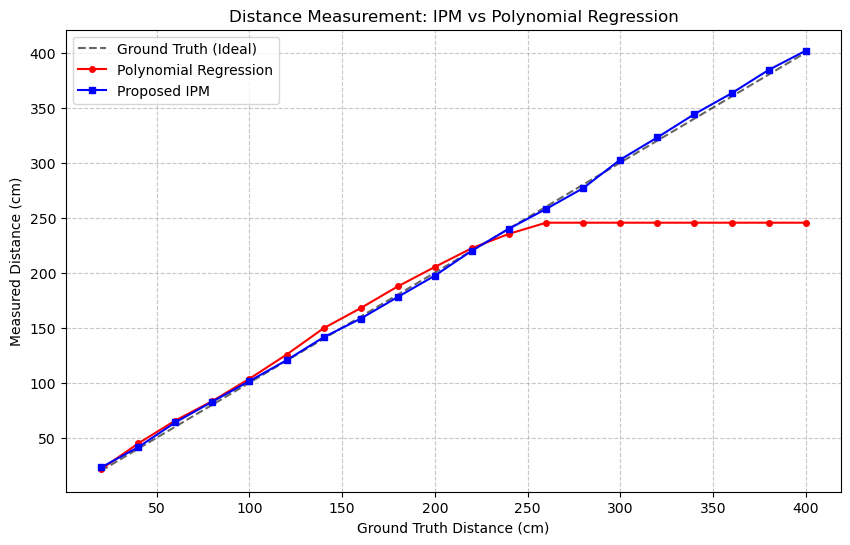

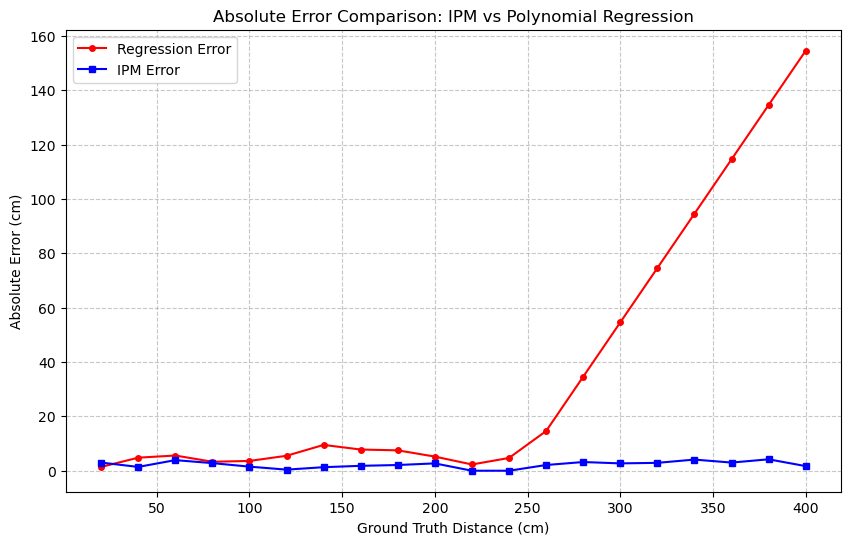

In [3]:
df = pd.read_csv("../data/regression_vs_ipm.csv")

# Calculate absolute error
df['regression_error'] = (df['regression'] - df['dist']).abs()
df['ipm_error'] = (df['ipm'] - df['dist']).abs()

# Plot 1: Distance Measurement Comparison
plt.figure(figsize=(10, 6))
plt.plot(df['dist'], df['dist'], 'k--', label='Ground Truth (Ideal)', alpha=0.6)
plt.plot(df['dist'], df['regression'], 'r-o', label='Polynomial Regression', markersize=4)
plt.plot(df['dist'], df['ipm'], 'b-s', label='Proposed IPM', markersize=4)
plt.ylabel('Measured Distance (cm)')
plt.xlabel('Ground Truth Distance (cm)')
plt.title('Distance Measurement: IPM vs Polynomial Regression')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

# Plot 2: Absolute Error Comparison
plt.figure(figsize=(10, 6))
plt.plot(df['dist'], df['regression_error'], 'r-o', label='Regression Error', markersize=4)
plt.plot(df['dist'], df['ipm_error'], 'b-s', label='IPM Error', markersize=4)
plt.xlabel('Ground Truth Distance (cm)')
plt.ylabel('Absolute Error (cm)')
plt.title('Absolute Error Comparison: IPM vs Polynomial Regression')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)